# Notebook 2 — Exploratory Data Analysis (EDA)
### Pakistan Export Demand Forecasting System | Final Year Project

---

## Purpose
Understand the data deeply before modeling. Every chart here answers a specific question that will inform our modeling decisions in Notebook 3.

## Table of Contents
1. [Dataset Overview](#1) — Shape, types, null check, descriptive stats
2. [Export Value Distribution](#2) — How large is each commodity? How volatile?
3. [Time Series Trends](#3) — How have exports changed from 2010 to 2025?
4. [Seasonality Analysis](#4) — Which months are peak export months per commodity?
5. [External Macroeconomic Drivers](#5) — How do USD/PKR, Oil, and US Confidence behave?
6. [Correlation Analysis](#6) — Which features are most related to the target?
7. [Lag & Rolling Feature Validation](#7) — Do past exports predict future exports?
8. [Key Insights Summary](#8) — What did we learn?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='tab10')

# Short human-readable labels for each HS Code (used in all charts)
HS_LABELS = {
    '1006': 'Rice',
    '1207': 'Oil Seeds',
    '2523': 'Cement',
    '5205': 'Cotton Yarn',
    '6110': 'Winter Wear',
    '6203': 'Mens Suits',
    '6302': 'Bed Linens',
    '7403': 'Copper',
    '9018': 'Medical Instr.',
    '9506': 'Sports Goods',
}

# 10 distinct colors for 10 commodities
COLORS = list(plt.cm.tab10.colors)

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
<a id='1'></a>
## Section 1 — Dataset Overview
Load the master dataset and confirm it is clean and correctly structured before any analysis.

In [2]:
DATA_PATH = Path('..') / 'Data' / 'Master_FYP_Dataset.csv'
df = pd.read_csv(DATA_PATH, dtype={'HS_Code': str})

# Proper datetime column for clean x-axis labels on all time series plots
df['Date'] = pd.to_datetime(df['Date_YYYYMM'].astype(str), format='%Y%m')

# Add short commodity label column
df['Commodity'] = df['HS_Code'].map(HS_LABELS)

print(f'Shape          : {df.shape}')
print(f'Date range     : {df["Date"].min().strftime("%b %Y")}  to  {df["Date"].max().strftime("%b %Y")}')
print(f'Commodities    : {df["Commodity"].nunique()}  |  {sorted(df["Commodity"].unique())}')
print(f'\nNull values per column:')
print(df.isnull().sum())
print(f'\nColumn types:')
print(df.dtypes)

Shape          : (1860, 18)
Date range     : Jul 2010  to  Dec 2025
Commodities    : 10  |  ['Bed Linens', 'Cement', 'Copper', 'Cotton Yarn', 'Medical Instr.', 'Mens Suits', 'Oil Seeds', 'Rice', 'Sports Goods', 'Winter Wear']

Null values per column:
Date_YYYYMM               0
HS_Code                   0
Commodity_Name            0
Export_Value_USD          0
USD_PKR_Close             0
Brent_Oil_Avg             0
US_Consumer_Confidence    0
Year                      0
Month                     0
Month_Sin                 0
Month_Cos                 0
Lag_1M                    0
Lag_3M                    0
Lag_6M                    0
Rolling_3M_Avg            0
Rolling_6M_Avg            0
Date                      0
Commodity                 0
dtype: int64

Column types:
Date_YYYYMM                        int64
HS_Code                              str
Commodity_Name                       str
Export_Value_USD                 float64
USD_PKR_Close                    float64
Brent_Oil_Av

In [3]:
# Descriptive statistics for all numeric features
print('Descriptive Statistics (USD values in raw dollars):')
df.describe().round(2)

Descriptive Statistics (USD values in raw dollars):


,Date_YYYYMM,Export_Value_USD,USD_PKR_Close,Brent_Oil_Avg,US_Consumer_Confidence,Year,Month,Month_Sin,Month_Cos,Lag_1M,Lag_3M,Lag_6M,Rolling_3M_Avg,Rolling_6M_Avg,Date
count,1860.00,1.860000e+03,1860.00,1860.00,1860.00,1860.00,1860.00,1860.00,1860.00,1.860000e+03,1.860000e+03,1.860000e+03,1.860000e+03,1.860000e+03,1860
mean,201780.79,8.922641e+07,153.43,77.68,79.46,2017.74,6.60,-0.02,0.01,8.906111e+07,8.852833e+07,8.783448e+07,8.879728e+07,8.844285e+07,2018-03-17 06:34:50.322580
min,201007.00,0.000000e+00,84.18,26.63,50.00,2010.00,1.00,-1.00,-1.00,0.000000e+00,0.000000e+00,0.000000e+00,5.694000e+01,1.163661e+05,2010-07-01 00:00:00
25%,201405.00,1.800844e+07,101.60,60.12,69.10,2014.00,4.00,-0.87,-0.50,1.799149e+07,1.788857e+07,1.760896e+07,1.815986e+07,1.875780e+07,2014-05-01 00:00:00
50%,201803.50,3.880044e+07,115.38,74.97,79.00,2018.00,7.00,-0.00,-0.00,3.878239e+07,3.876636e+07,3.852261e+07,3.825561e+07,3.798597e+07,2018-03-16 12:00:00
75%,202202.00,1.439444e+08,177.95,102.86,93.00,2022.00,10.00,0.50,0.87,1.438971e+08,1.434753e+08,1.422087e+08,1.505293e+08,1.557979e+08,2022-02-01 00:00:00
max,202512.00,5.184698e+08,303.23,124.54,101.40,2025.00,12.00,1.00,1.00,5.184698e+08,5.184698e+08,5.184698e+08,4.678947e+08,4.284133e+08,2025-12-01 00:00:00
std,447.88,9.843502e+07,70.31,23.78,13.89,4.48,3.45,0.71,0.71,9.832307e+07,9.793605e+07,9.733563e+07,9.708737e+07,9.596702e+07,NaN


In [4]:
# Per-commodity summary — mean, std, min, max, and Coefficient of Variation (CV)
# CV = Std / Mean * 100 — higher CV means more volatile / harder to predict
summary = df.groupby('Commodity').agg(
    Months=('Export_Value_USD', 'count'),
    Mean_USD_M=('Export_Value_USD', lambda x: x.mean() / 1e6),
    Std_USD_M=('Export_Value_USD', lambda x: x.std() / 1e6),
    Min_USD_M=('Export_Value_USD', lambda x: x.min() / 1e6),
    Max_USD_M=('Export_Value_USD', lambda x: x.max() / 1e6),
    CV_pct=('Export_Value_USD', lambda x: x.std() / x.mean() * 100)
).round(2)

summary = summary.sort_values('Mean_USD_M', ascending=False)
print('Per-Commodity Summary (values in USD Millions | CV = volatility indicator)')
summary

Per-Commodity Summary (values in USD Millions | CV = volatility indicator)


,Months,Mean_USD_M,Std_USD_M,Min_USD_M,Max_USD_M,CV_pct
Commodity,,,,,,
Bed Linens,186,282.37,61.33,99.12,442.11,21.72
Rice,186,188.41,72.05,75.49,518.47,38.24
Mens Suits,186,163.12,72.83,46.20,306.78,44.65
Cotton Yarn,186,110.29,46.51,35.93,244.36,42.17
Winter Wear,186,34.64,27.70,2.53,106.48,79.94
Medical Instr.,186,31.13,5.90,12.05,43.73,18.94
Cement,186,28.19,12.07,4.45,59.29,42.80
Copper,186,23.81,27.54,0.00,94.70,115.68
Sports Goods,186,20.76,5.41,5.13,33.79,26.08


---
<a id='2'></a>
## Section 2 — Export Value Distribution

**Question:** How large is each commodity in USD terms, and how spread out are its values?

This matters because our model must handle commodities with very different value scales — from Oil Seeds (~$1M/month) to Bed Linens (~$250M/month). The `HS_Code` categorical feature helps the model learn a separate response function per commodity.

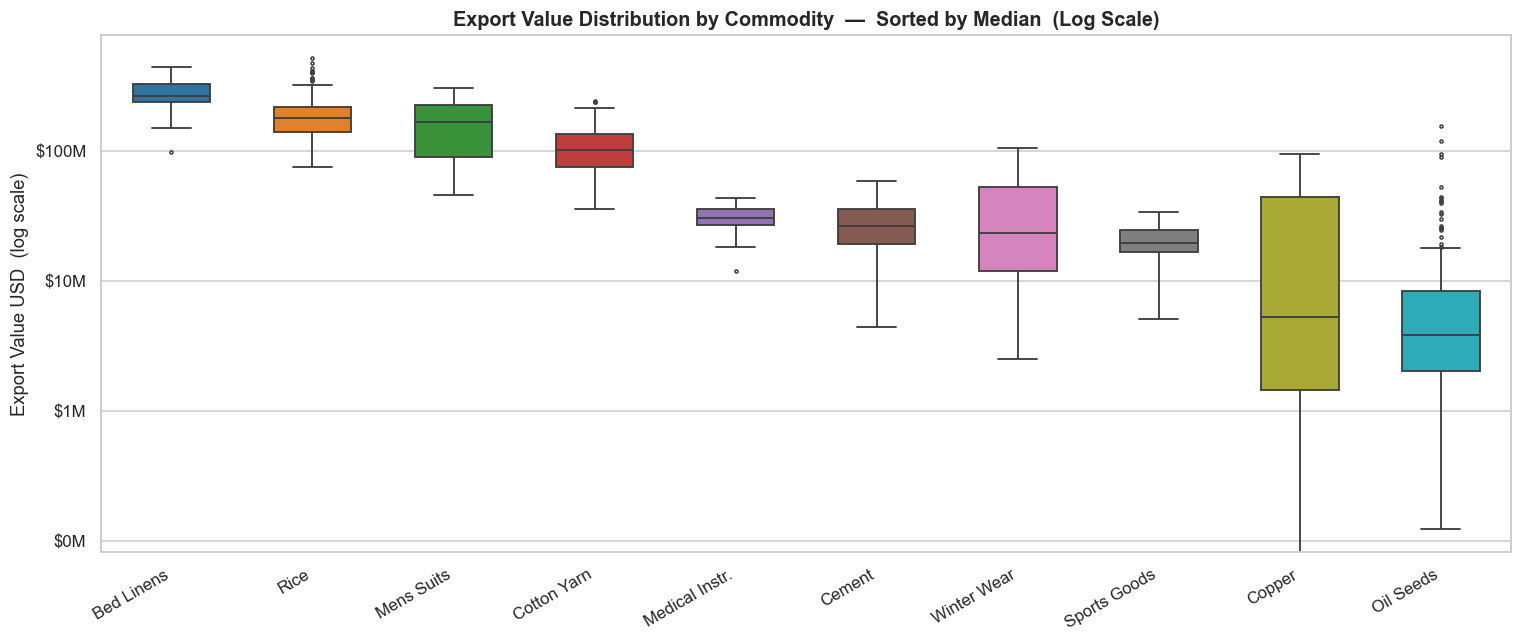

Log scale is used because the range spans from ~$100K (Oil Seeds) to ~$400M (Bed Linens).
Copper shows the widest box (highest variance) due to its erratic trade patterns and zero-fill months.


In [5]:
# Sort commodities by median export value (highest to lowest)
order = (
    df.groupby('Commodity')['Export_Value_USD']
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=df,
    x='Commodity',
    y='Export_Value_USD',
    order=order,
    palette='tab10',
    ax=ax,
    width=0.55,
    fliersize=2,
    linewidth=1.2
)

# Log scale is essential here — without it, small commodities are invisible
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.set_xlabel('')
ax.set_ylabel('Export Value USD  (log scale)')
ax.set_title('Export Value Distribution by Commodity  —  Sorted by Median  (Log Scale)', 
             fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('Log scale is used because the range spans from ~$100K (Oil Seeds) to ~$400M (Bed Linens).')
print('Copper shows the widest box (highest variance) due to its erratic trade patterns and zero-fill months.')

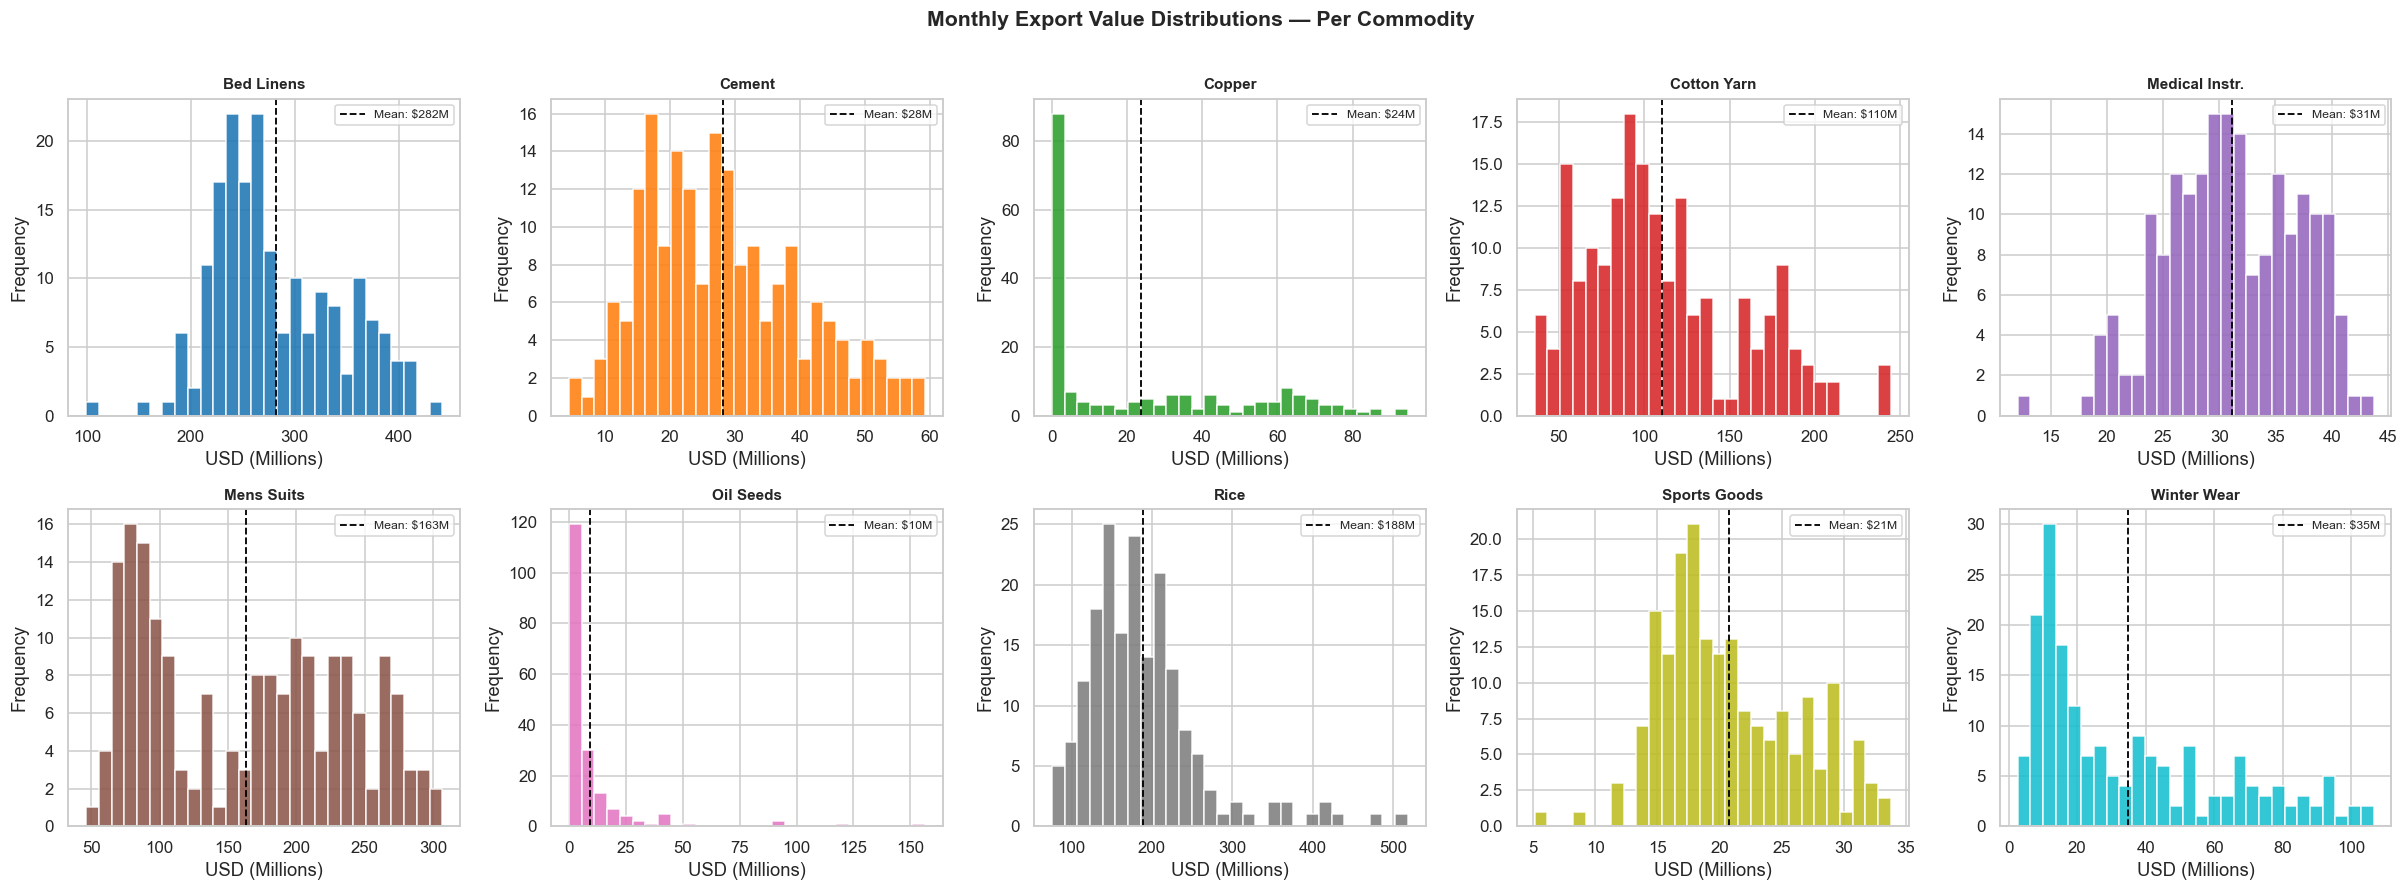

In [6]:
# Individual distribution for each commodity
sorted_comms = sorted(df['Commodity'].unique())

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for i, comm in enumerate(sorted_comms):
    sub = df[df['Commodity'] == comm]['Export_Value_USD'] / 1e6
    axes[i].hist(sub, bins=28, color=COLORS[i], edgecolor='white', alpha=0.88)
    axes[i].set_title(comm, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('USD (Millions)')
    axes[i].set_ylabel('Frequency')
    # Show mean line
    axes[i].axvline(sub.mean(), color='black', linestyle='--', linewidth=1.2, label=f'Mean: ${sub.mean():.0f}M')
    axes[i].legend(fontsize=8)

plt.suptitle('Monthly Export Value Distributions — Per Commodity', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
<a id='3'></a>
## Section 3 — Time Series Trends

**Question:** How have exports changed over the 15-year window (2010–2025)?

Key events to look for:
- **COVID-19 (Mar–Sep 2020):** Disrupted global supply chains — expect a visible dip
- **PKR devaluation (2018–2023):** Made Pakistani exports cheaper in USD → may boost volume but reduce USD value
- **Commodity-specific shocks:** Cotton Yarn decline, Winter Wear growth

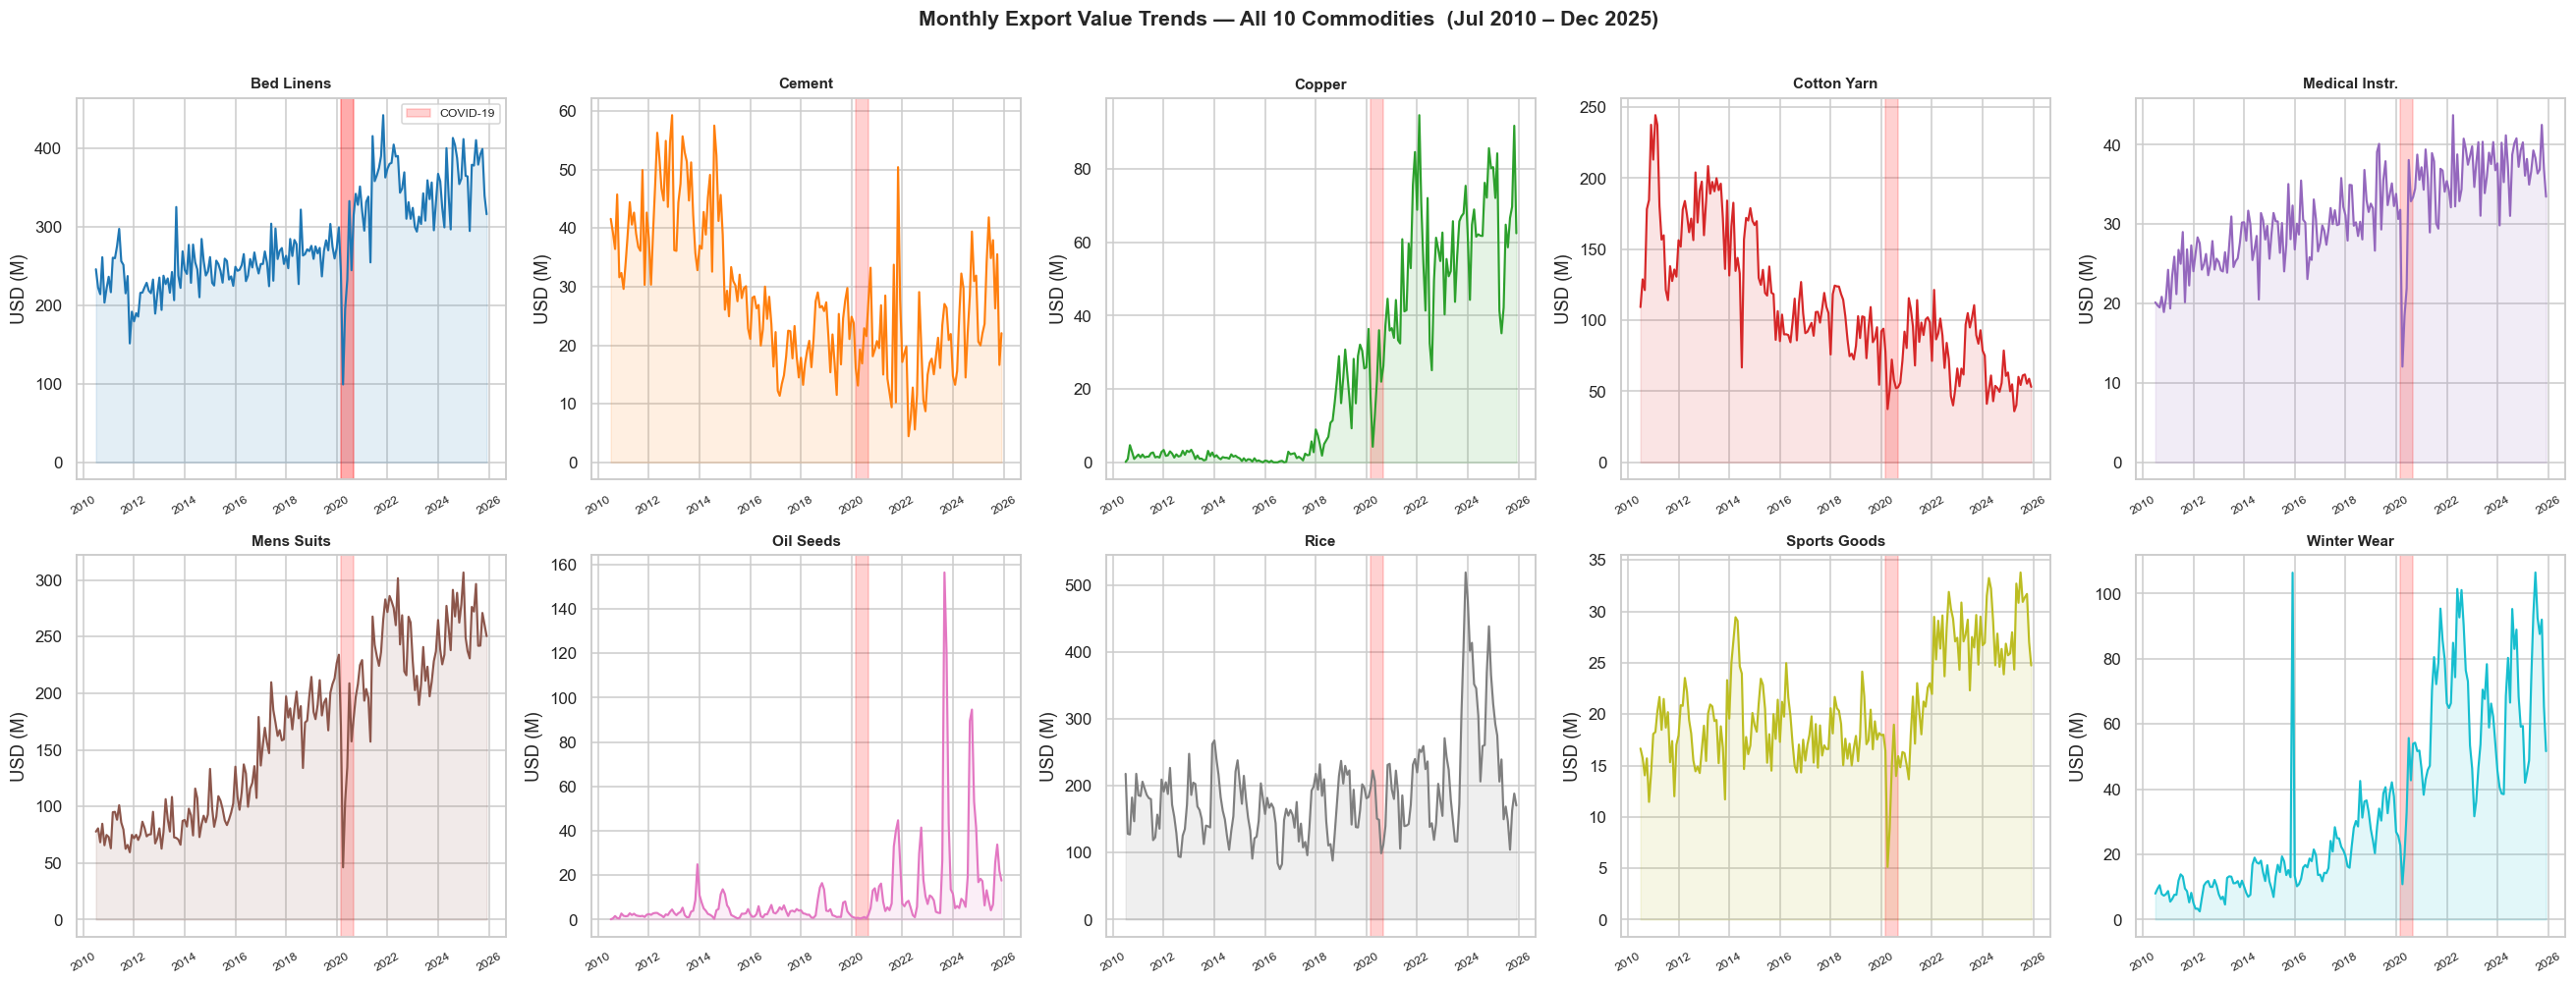

In [7]:
# 10-panel time series — one subplot per commodity
fig, axes = plt.subplots(2, 5, figsize=(24, 9), sharey=False)
axes = axes.flatten()
covid_start = pd.Timestamp('2020-03-01')
covid_end   = pd.Timestamp('2020-09-01')

for i, comm in enumerate(sorted_comms):
    sub = df[df['Commodity'] == comm].sort_values('Date')
    axes[i].plot(sub['Date'], sub['Export_Value_USD'] / 1e6, color=COLORS[i], linewidth=1.4)
    axes[i].fill_between(sub['Date'], sub['Export_Value_USD'] / 1e6, alpha=0.12, color=COLORS[i])
    axes[i].axvspan(covid_start, covid_end, alpha=0.18, color='red')
    axes[i].set_title(comm, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('USD (M)')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)

# Add a shared COVID label on the first plot
axes[0].axvspan(covid_start, covid_end, alpha=0.18, color='red', label='COVID-19')
axes[0].legend(fontsize=8)

plt.suptitle('Monthly Export Value Trends — All 10 Commodities  (Jul 2010 – Dec 2025)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

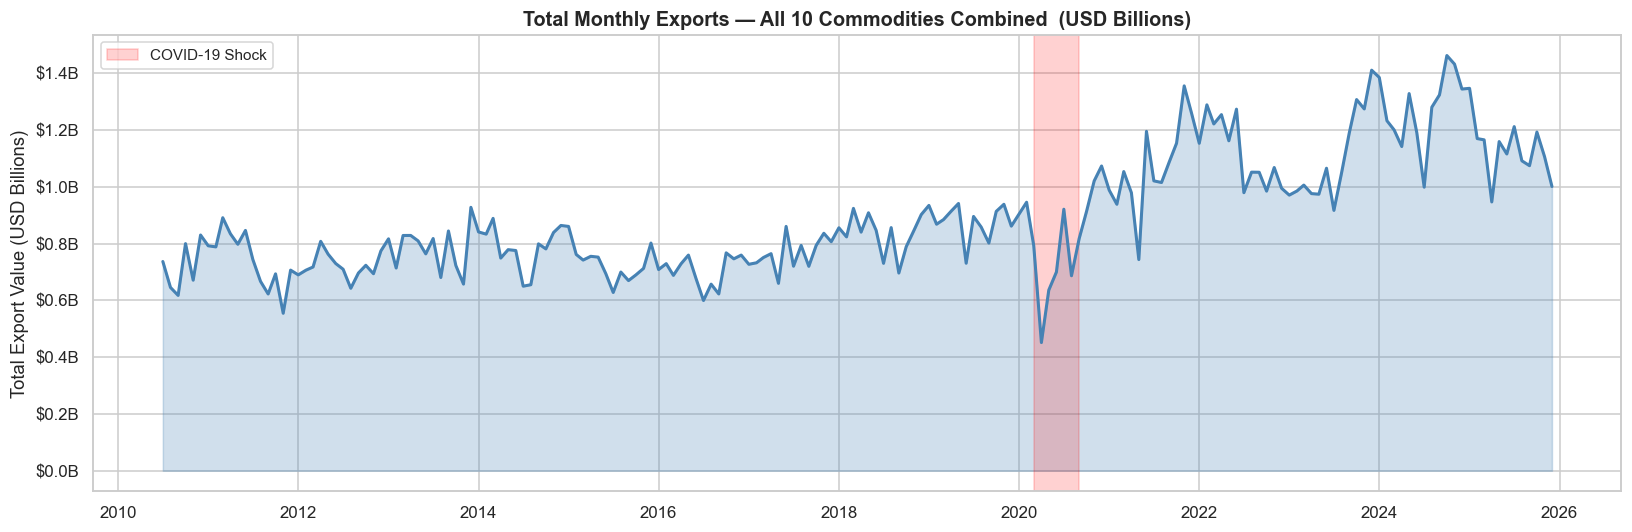

Peak combined export month : Oct 2024  —  $1.46B


In [8]:
# Total exports across all 10 commodities combined — monthly aggregate
agg = df.groupby('Date')['Export_Value_USD'].sum().reset_index()

fig, ax = plt.subplots(figsize=(15, 5))
ax.fill_between(agg['Date'], agg['Export_Value_USD'] / 1e9, alpha=0.25, color='steelblue')
ax.plot(agg['Date'], agg['Export_Value_USD'] / 1e9, color='steelblue', linewidth=2)
ax.axvspan(covid_start, covid_end, alpha=0.18, color='red', label='COVID-19 Shock')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}B'))
ax.set_ylabel('Total Export Value (USD Billions)')
ax.set_title('Total Monthly Exports — All 10 Commodities Combined  (USD Billions)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

peak = agg.loc[agg['Export_Value_USD'].idxmax()]
print(f'Peak combined export month : {peak["Date"].strftime("%b %Y")}  —  ${peak["Export_Value_USD"]/1e9:.2f}B')

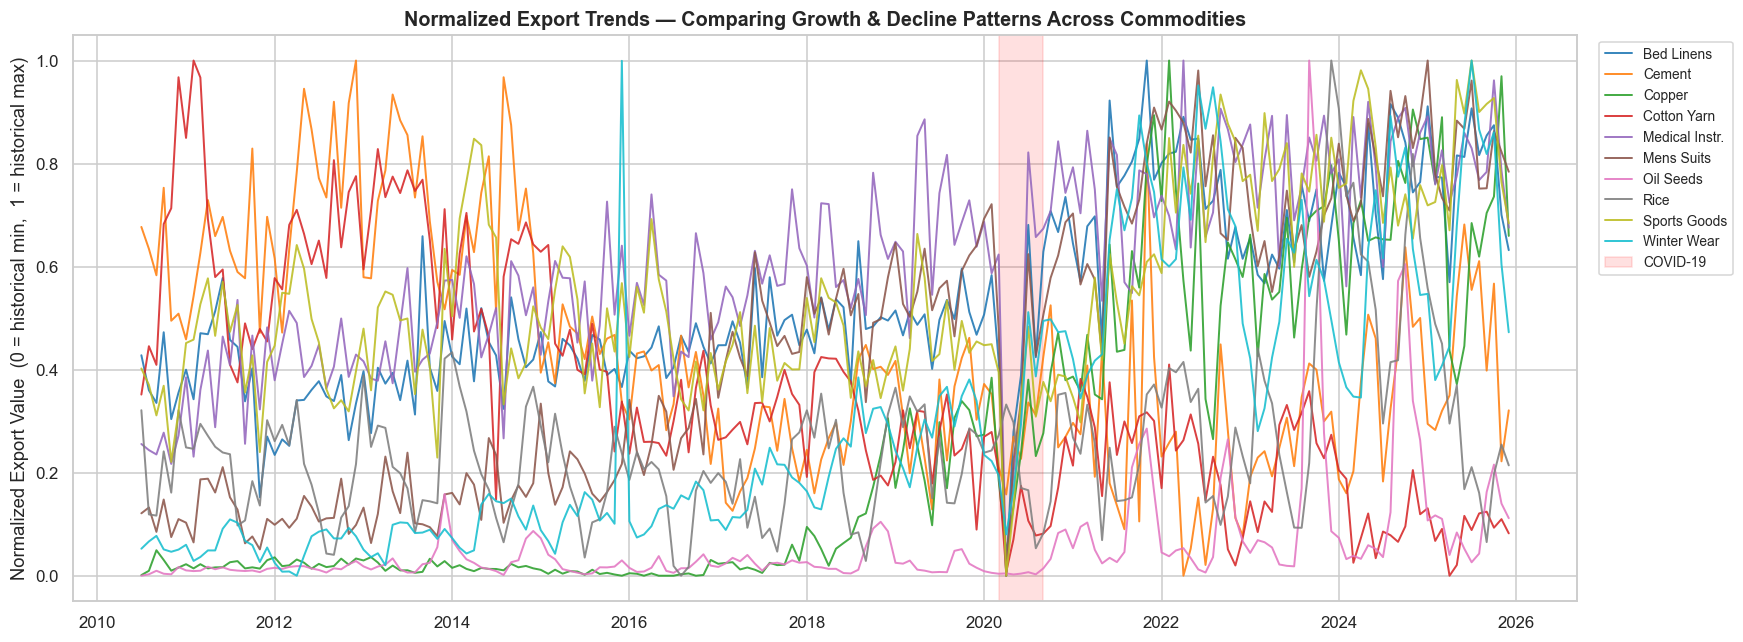

Commodities trending toward 1.0 at the right edge = growing exporters (e.g. Copper, Winter Wear)
Commodities trending toward 0.0 = declining or stagnant (e.g. Cotton Yarn, Oil Seeds)


In [9]:
# Normalized overlay — scale every commodity to 0-1 so we can compare growth SHAPES
# (removes scale differences; shows which commodities are growing vs declining)
fig, ax = plt.subplots(figsize=(16, 6))

for i, comm in enumerate(sorted_comms):
    sub = df[df['Commodity'] == comm].sort_values('Date')
    series = sub['Export_Value_USD']
    norm   = (series - series.min()) / (series.max() - series.min())
    ax.plot(sub['Date'], norm, label=comm, color=COLORS[i], linewidth=1.3, alpha=0.88)

ax.axvspan(covid_start, covid_end, alpha=0.12, color='red', label='COVID-19')
ax.set_ylabel('Normalized Export Value  (0 = historical min,  1 = historical max)')
ax.set_title('Normalized Export Trends — Comparing Growth & Decline Patterns Across Commodities', 
             fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print('Commodities trending toward 1.0 at the right edge = growing exporters (e.g. Copper, Winter Wear)')
print('Commodities trending toward 0.0 = declining or stagnant (e.g. Cotton Yarn, Oil Seeds)')

---
<a id='4'></a>
## Section 4 — Seasonality Analysis

**Question:** Do exports follow predictable monthly patterns?

Strong seasonality is a signal that our `Month_Sin` and `Month_Cos` features will be useful. For example:
- **Winter Wear (6110):** Orders placed by Western retailers before their winter — expect Q2/Q3 peaks
- **Rice (1006):** Post-harvest (Oct–Dec) export surge
- **Bed Linens (6302):** Relatively consistent year-round demand

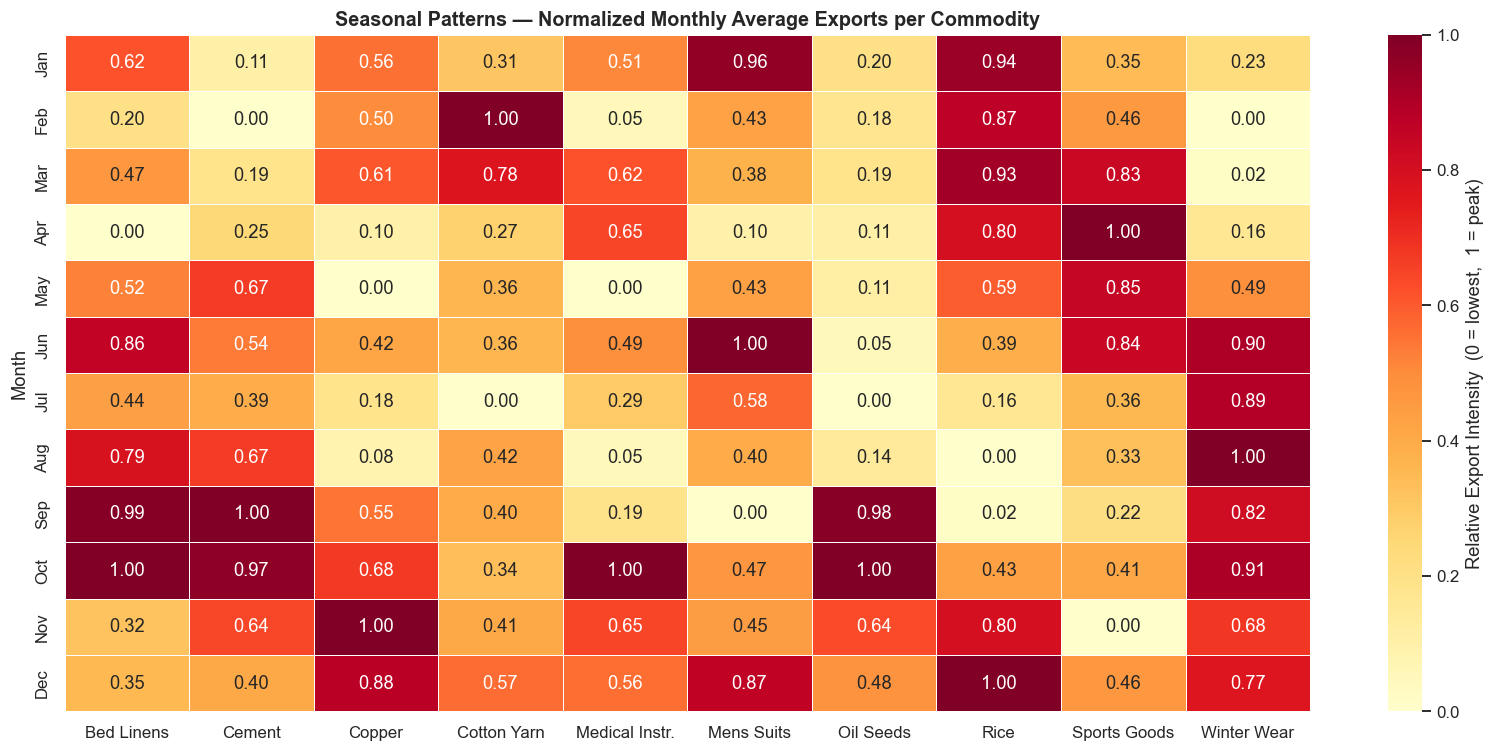

Red cells = peak export months.  Yellow cells = low season.
Note how Winter Wear peaks in summer (Jul-Aug) — western retailers order 5-6 months ahead of their winter.


In [10]:
# Seasonal heatmap — rows = Month, columns = Commodity
# Values normalized per commodity (0=lowest month, 1=peak month)
# so commodities of different scales can be compared side by side

seasonal = df.groupby(['Commodity', 'Month'])['Export_Value_USD'].mean().reset_index()
pivot = seasonal.pivot(index='Month', columns='Commodity', values='Export_Value_USD')

pivot_norm = (pivot - pivot.min()) / (pivot.max() - pivot.min())
pivot_norm.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(
    pivot_norm,
    cmap='YlOrRd',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Relative Export Intensity  (0 = lowest,  1 = peak)'}
)
ax.set_title('Seasonal Patterns — Normalized Monthly Average Exports per Commodity', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Month')
plt.tight_layout()
plt.show()

print('Red cells = peak export months.  Yellow cells = low season.')
print('Note how Winter Wear peaks in summer (Jul-Aug) — western retailers order 5-6 months ahead of their winter.')

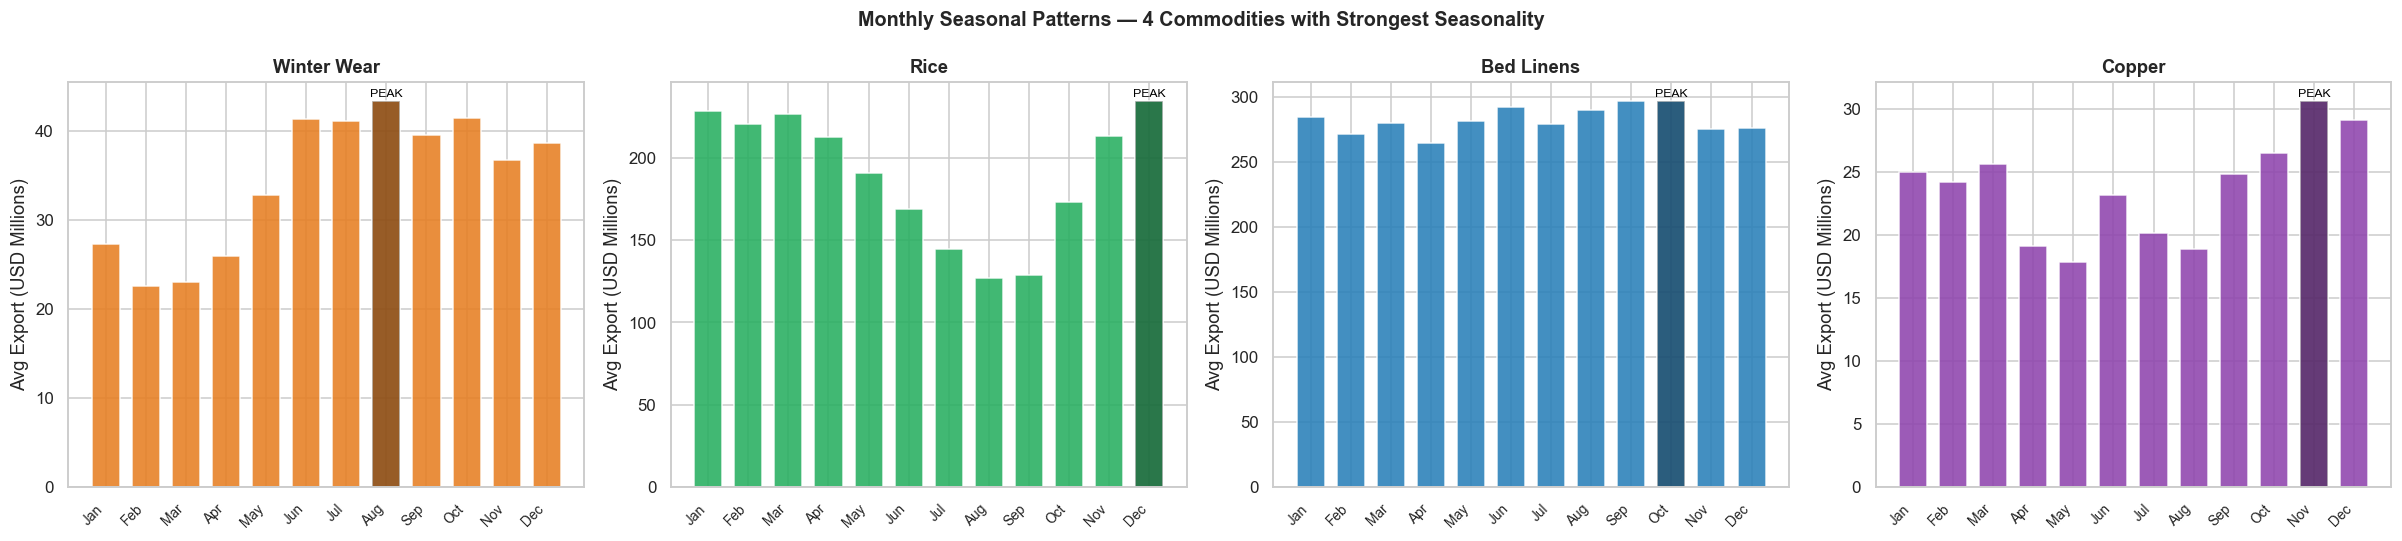

In [11]:
# Seasonal bar charts for 4 commodities with the most distinct seasonality
highlight = ['Winter Wear', 'Rice', 'Bed Linens', 'Copper']
bar_colors = ['#e67e22', '#27ae60', '#2980b9', '#8e44ad']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for i, (comm, color) in enumerate(zip(highlight, bar_colors)):
    monthly_avg = df[df['Commodity'] == comm].groupby('Month')['Export_Value_USD'].mean() / 1e6
    axes[i].bar(range(1, 13), monthly_avg.values, color=color, edgecolor='white', alpha=0.88, width=0.7)
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(month_labels, rotation=45, ha='right', fontsize=9)
    axes[i].set_title(comm, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Avg Export (USD Millions)')
    # Highlight peak month
    peak_month = monthly_avg.idxmax()
    axes[i].bar(peak_month, monthly_avg[peak_month], color='black', alpha=0.35, width=0.7)
    axes[i].text(peak_month, monthly_avg[peak_month] * 1.01, 'PEAK', ha='center', fontsize=8, color='black')

plt.suptitle('Monthly Seasonal Patterns — 4 Commodities with Strongest Seasonality', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='5'></a>
## Section 5 — External Macroeconomic Drivers

**Question:** How do the three global economic drivers behave over time, and do they visually correlate with export changes?

- **USD/PKR:** As the rupee weakens, Pakistani goods become cheaper for foreign buyers → potential export boost
- **Brent Oil:** High oil = high shipping costs = squeeze on profit margins for exporters
- **US Consumer Confidence:** When US consumers feel rich, they buy more imported goods (apparel, linens, sports goods)

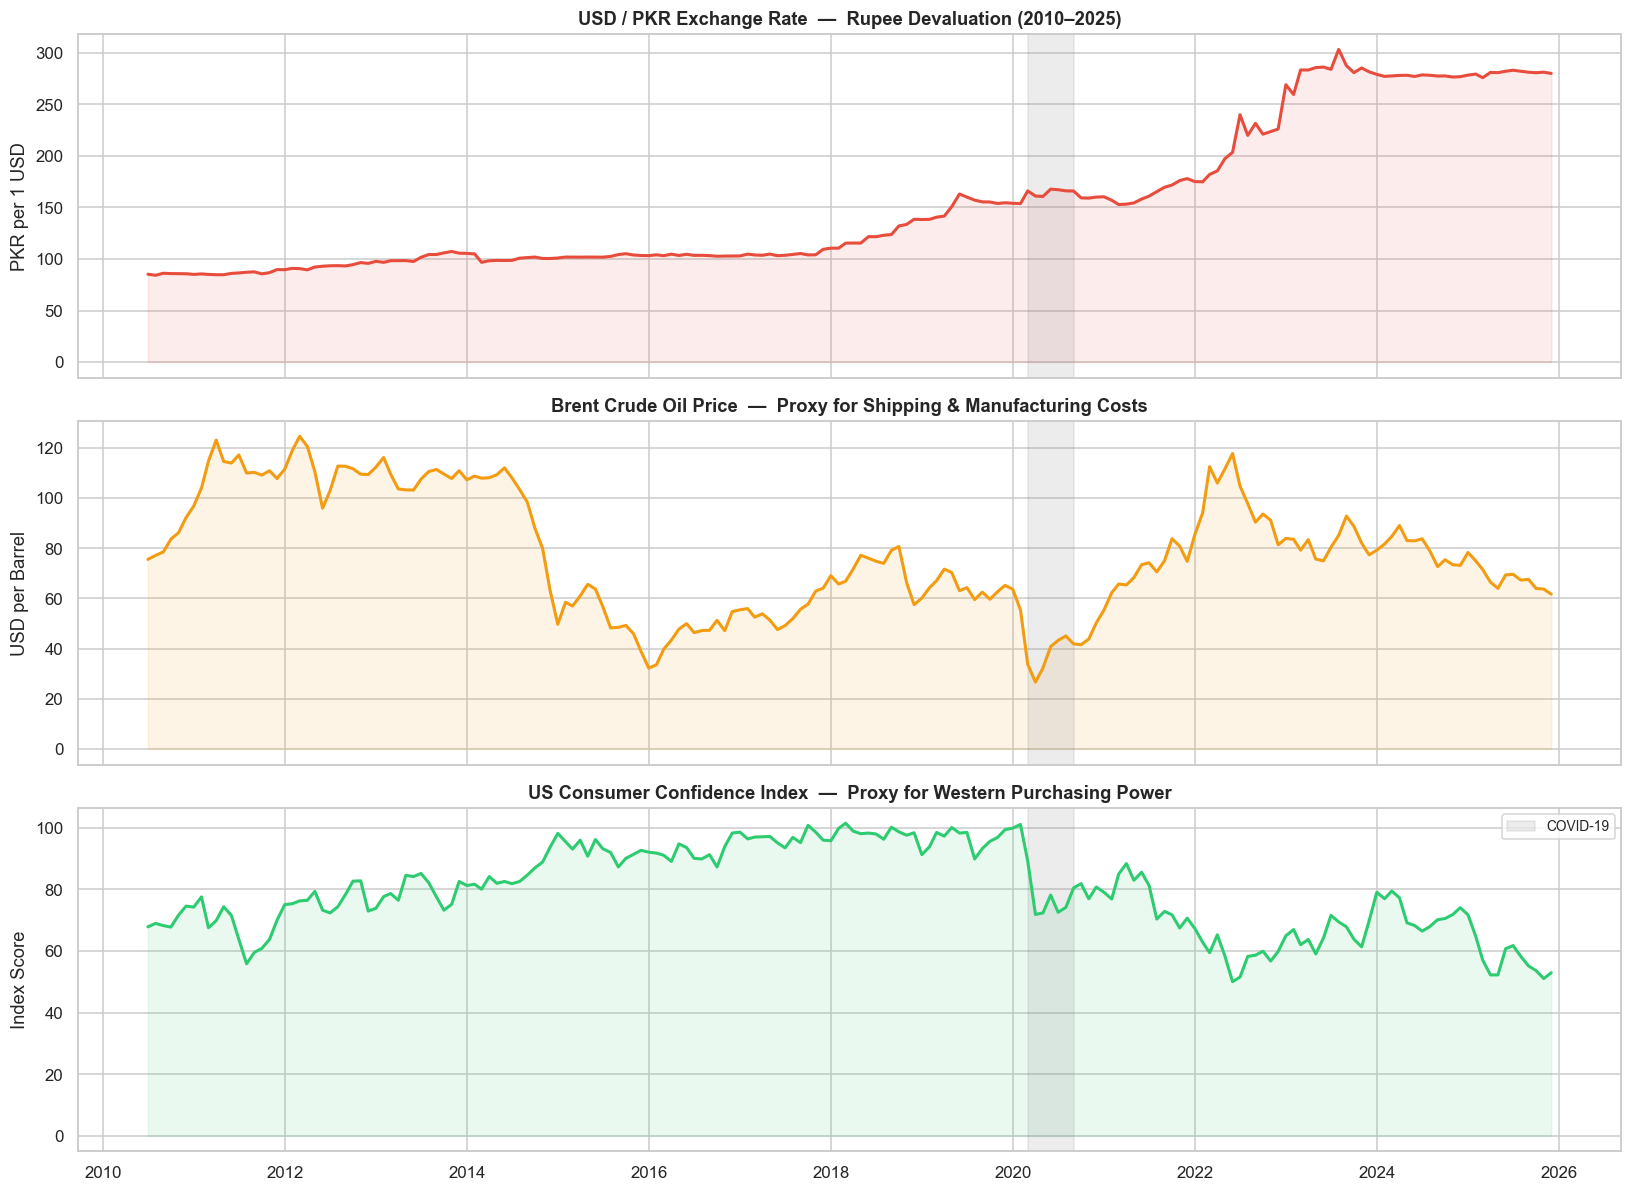

USD/PKR range   : 84.2  to  303.2  PKR  (3.3x devaluation)
Brent Oil range : $26.6  to  $124.5  per barrel
US Confidence   : 50.0  to  101.4  (declining in 2025)


In [12]:
# One row per date (all 10 commodity rows share the same driver values, so just deduplicate)
driver_df = df.drop_duplicates('Date').sort_values('Date').reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

# --- USD/PKR ---
axes[0].plot(driver_df['Date'], driver_df['USD_PKR_Close'], color='#e74c3c', linewidth=2)
axes[0].fill_between(driver_df['Date'], driver_df['USD_PKR_Close'], alpha=0.1, color='#e74c3c')
axes[0].set_ylabel('PKR per 1 USD')
axes[0].set_title('USD / PKR Exchange Rate  —  Rupee Devaluation (2010–2025)', fontweight='bold')
axes[0].axvspan(covid_start, covid_end, alpha=0.15, color='gray')

# --- Brent Oil ---
axes[1].plot(driver_df['Date'], driver_df['Brent_Oil_Avg'], color='#f39c12', linewidth=2)
axes[1].fill_between(driver_df['Date'], driver_df['Brent_Oil_Avg'], alpha=0.1, color='#f39c12')
axes[1].set_ylabel('USD per Barrel')
axes[1].set_title('Brent Crude Oil Price  —  Proxy for Shipping & Manufacturing Costs', fontweight='bold')
axes[1].axvspan(covid_start, covid_end, alpha=0.15, color='gray')

# --- US Consumer Confidence ---
axes[2].plot(driver_df['Date'], driver_df['US_Consumer_Confidence'], color='#2ecc71', linewidth=2)
axes[2].fill_between(driver_df['Date'], driver_df['US_Consumer_Confidence'], alpha=0.1, color='#2ecc71')
axes[2].set_ylabel('Index Score')
axes[2].set_title('US Consumer Confidence Index  —  Proxy for Western Purchasing Power', fontweight='bold')
axes[2].axvspan(covid_start, covid_end, alpha=0.15, color='gray', label='COVID-19')
axes[2].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

print(f'USD/PKR range   : {driver_df["USD_PKR_Close"].min():.1f}  to  {driver_df["USD_PKR_Close"].max():.1f}  PKR  (3.3x devaluation)')
print(f'Brent Oil range : ${driver_df["Brent_Oil_Avg"].min():.1f}  to  ${driver_df["Brent_Oil_Avg"].max():.1f}  per barrel')
print(f'US Confidence   : {driver_df["US_Consumer_Confidence"].min():.1f}  to  {driver_df["US_Consumer_Confidence"].max():.1f}  (declining in 2025)')

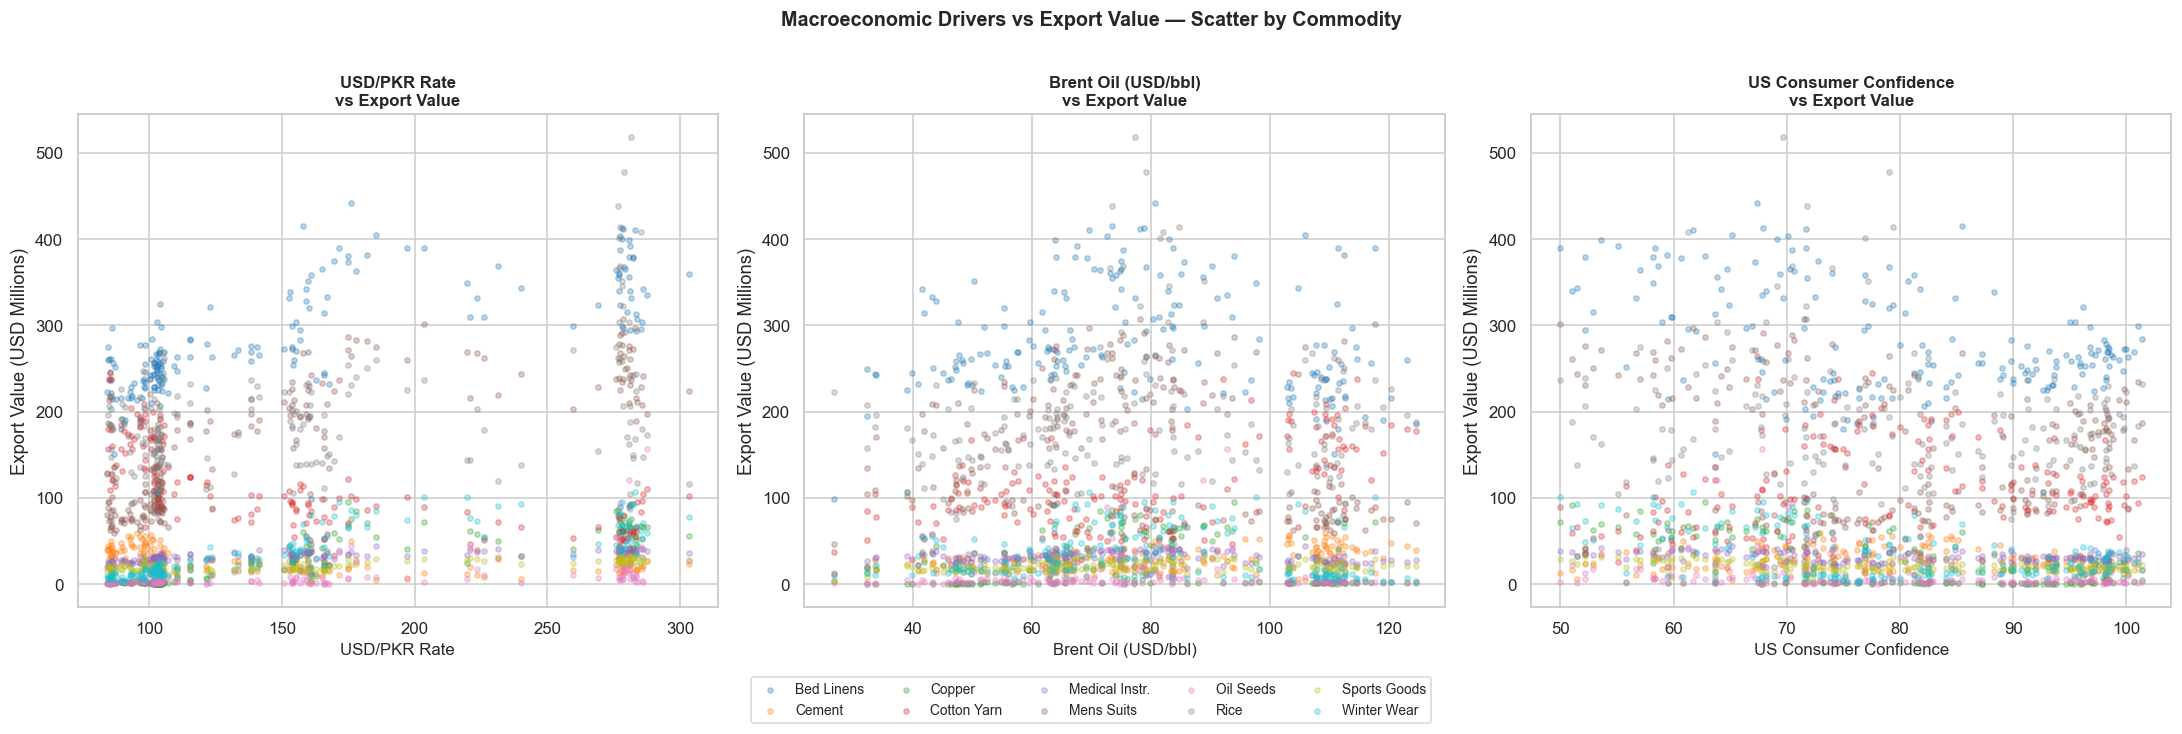

In [13]:
# Scatter plots: each driver vs Export_Value_USD, colored by commodity
drivers      = ['USD_PKR_Close', 'Brent_Oil_Avg', 'US_Consumer_Confidence']
driver_names = ['USD/PKR Rate', 'Brent Oil (USD/bbl)', 'US Consumer Confidence']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for col_idx, (driver, name) in enumerate(zip(drivers, driver_names)):
    for i, comm in enumerate(sorted_comms):
        sub = df[df['Commodity'] == comm]
        axes[col_idx].scatter(
            sub[driver],
            sub['Export_Value_USD'] / 1e6,
            alpha=0.3, s=12, color=COLORS[i], label=comm
        )
    axes[col_idx].set_xlabel(name, fontsize=11)
    axes[col_idx].set_ylabel('Export Value (USD Millions)')
    axes[col_idx].set_title(f'{name}\nvs Export Value', fontweight='bold', fontsize=11)

# Shared legend below all plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.08), fontsize=9, frameon=True)

plt.suptitle('Macroeconomic Drivers vs Export Value — Scatter by Commodity', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
<a id='6'></a>
## Section 6 — Correlation Analysis

**Question:** Which features have the strongest linear relationship with the target (`Export_Value_USD`)?

This guides feature importance understanding and tells us whether our engineered features (lags, rolling averages, seasonal encoding) are meaningful inputs for the model.

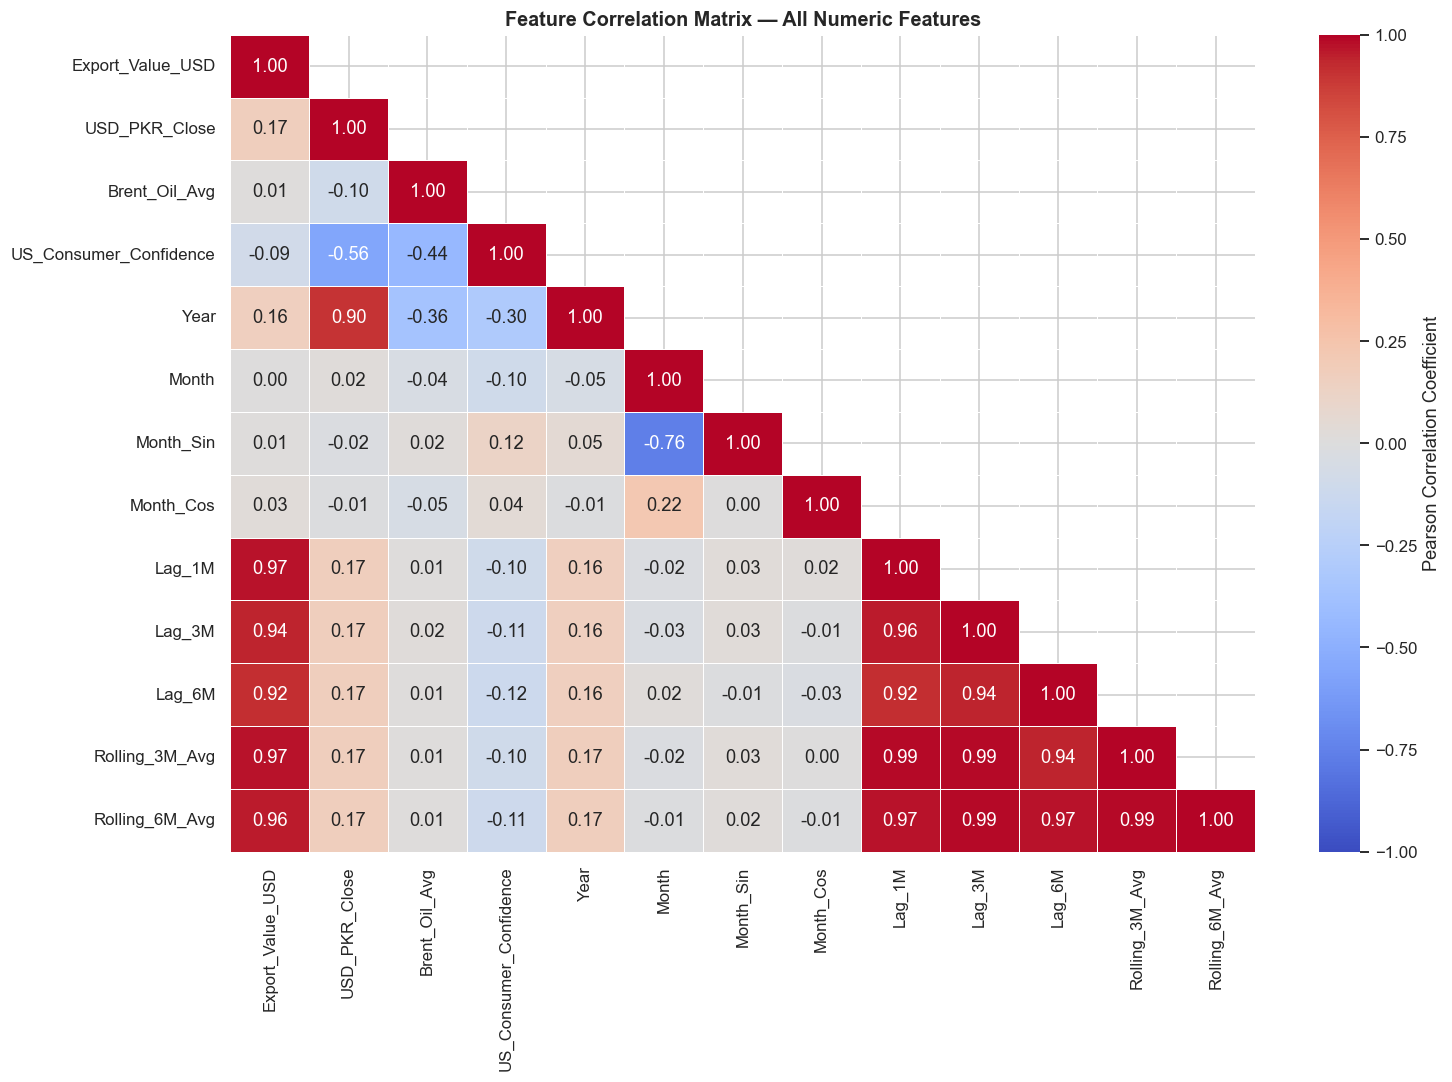

In [14]:
# Select all numeric model features for correlation analysis
numeric_cols = [
    'Export_Value_USD',
    'USD_PKR_Close', 'Brent_Oil_Avg', 'US_Consumer_Confidence',
    'Year', 'Month', 'Month_Sin', 'Month_Cos',
    'Lag_1M', 'Lag_3M', 'Lag_6M',
    'Rolling_3M_Avg', 'Rolling_6M_Avg'
]

corr = df[numeric_cols].corr().round(2)

# Show lower triangle only (removes redundant upper half)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)
ax.set_title('Feature Correlation Matrix — All Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

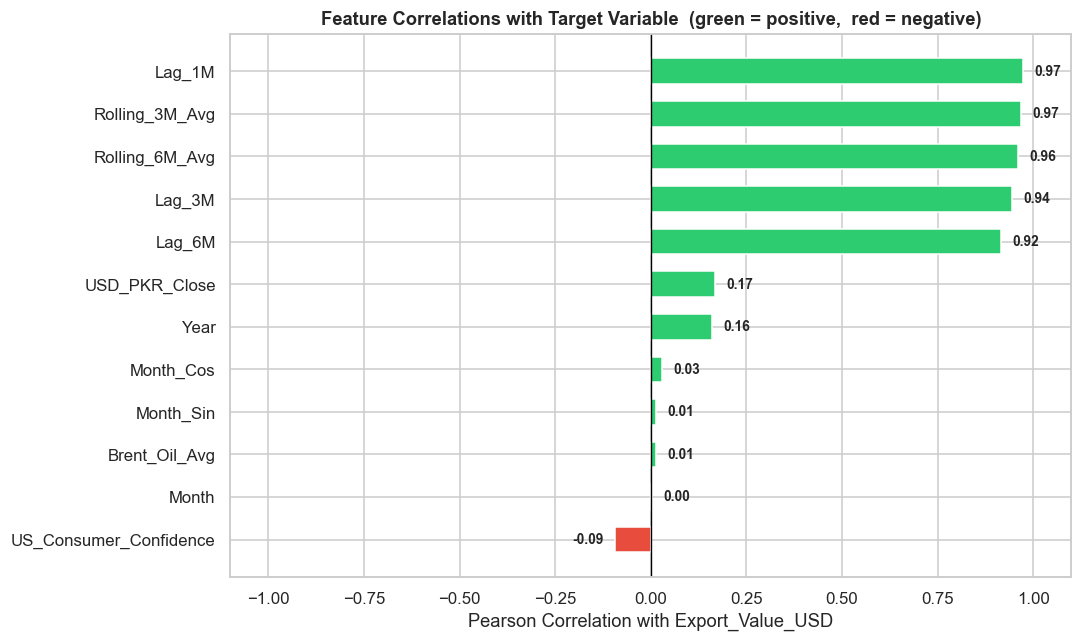

Top positive correlations: lag and rolling features confirm strong autocorrelation.
Year has a moderate positive correlation — exports have generally grown over time.
US Consumer Confidence shows a negative correlation — declining confidence in 2025 hurts demand.


In [15]:
# Extract correlations with target variable only, sorted
target_corr = (
    df[numeric_cols].corr()['Export_Value_USD']
    .drop('Export_Value_USD')
    .sort_values()
)

bar_colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in target_corr.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(target_corr.index, target_corr.values, color=bar_colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=0.9)
ax.set_xlabel('Pearson Correlation with Export_Value_USD')
ax.set_title('Feature Correlations with Target Variable  (green = positive,  red = negative)', 
             fontsize=12, fontweight='bold')
ax.set_xlim(-1.1, 1.1)

for bar, val in zip(bars, target_corr.values):
    offset = 0.03 if val >= 0 else -0.03
    align  = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', ha=align, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print('Top positive correlations: lag and rolling features confirm strong autocorrelation.')
print('Year has a moderate positive correlation — exports have generally grown over time.')
print('US Consumer Confidence shows a negative correlation — declining confidence in 2025 hurts demand.')

---
<a id='7'></a>
## Section 7 — Lag & Rolling Feature Validation

**Question:** Do past export values reliably predict future ones?

If the answer is yes (high lag correlations), then our lag and rolling features carry strong signal and the model will lean on them heavily. This is expected in trade data — exports are driven by contracts, infrastructure, and relationships that don't change overnight.

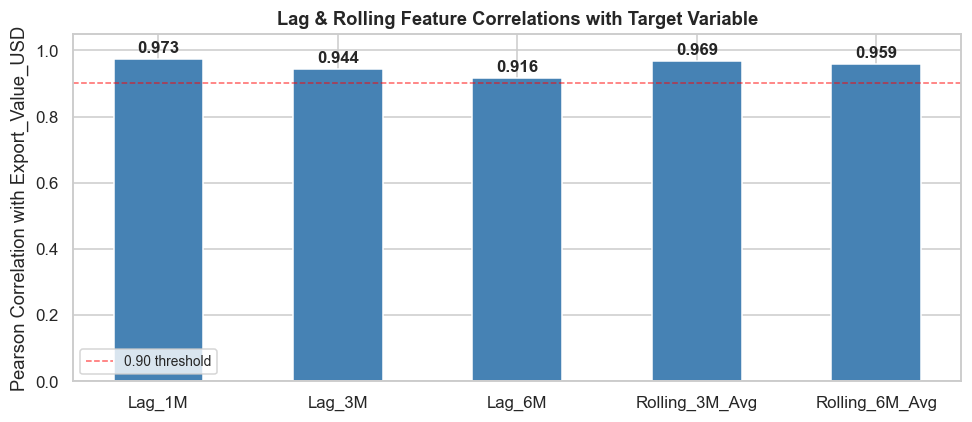

All five lag/rolling features show correlation > 0.90 with the target.
This is excellent — past exports are the strongest predictor of future exports.
Rolling averages slightly outperform raw lags, confirming that smoothed history is more stable.


In [16]:
# Correlation of each lag/rolling feature with the target
lag_cols  = ['Lag_1M', 'Lag_3M', 'Lag_6M', 'Rolling_3M_Avg', 'Rolling_6M_Avg']
lag_corrs = df[lag_cols + ['Export_Value_USD']].corr()['Export_Value_USD'].drop('Export_Value_USD')

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(lag_corrs.index, lag_corrs.values, color='steelblue', edgecolor='white', width=0.5)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Pearson Correlation with Export_Value_USD')
ax.set_title('Lag & Rolling Feature Correlations with Target Variable', 
             fontsize=12, fontweight='bold')
ax.axhline(0.9, color='red', linestyle='--', linewidth=1, alpha=0.6, label='0.90 threshold')
ax.legend(fontsize=9)

for bar, val in zip(bars, lag_corrs.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print('All five lag/rolling features show correlation > 0.90 with the target.')
print('This is excellent — past exports are the strongest predictor of future exports.')
print('Rolling averages slightly outperform raw lags, confirming that smoothed history is more stable.')

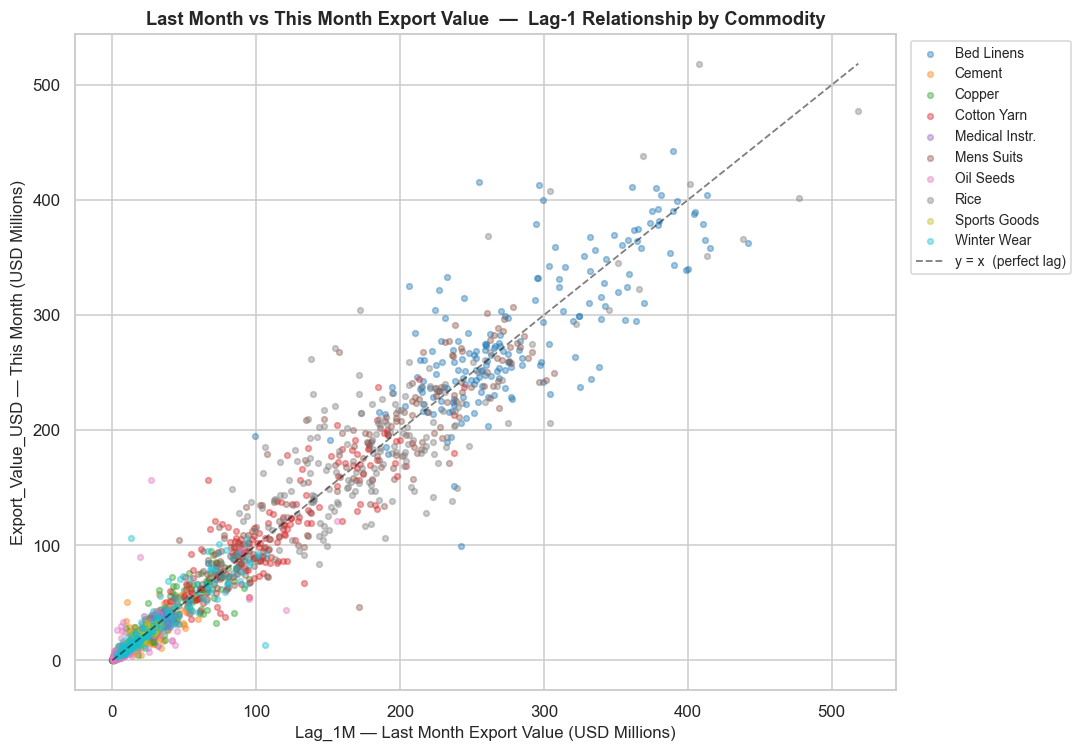

Points tightly clustered around the diagonal confirm that Lag_1M is a powerful predictor.
Each commodity cluster stays separate — the model must treat each HS_Code differently.


In [17]:
# Scatter: Lag_1M vs current Export_Value_USD — how close to the diagonal?
# Points on the dashed diagonal line = perfect prediction from last month
fig, ax = plt.subplots(figsize=(10, 7))

for i, comm in enumerate(sorted_comms):
    sub = df[df['Commodity'] == comm]
    ax.scatter(
        sub['Lag_1M'] / 1e6,
        sub['Export_Value_USD'] / 1e6,
        alpha=0.4, s=14, color=COLORS[i], label=comm
    )

# y = x reference line (perfect lag prediction)
max_val = max(df['Lag_1M'].max(), df['Export_Value_USD'].max()) / 1e6
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1.2, alpha=0.5, label='y = x  (perfect lag)')

ax.set_xlabel('Lag_1M — Last Month Export Value (USD Millions)', fontsize=11)
ax.set_ylabel('Export_Value_USD — This Month (USD Millions)', fontsize=11)
ax.set_title('Last Month vs This Month Export Value  —  Lag-1 Relationship by Commodity', 
             fontsize=12, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print('Points tightly clustered around the diagonal confirm that Lag_1M is a powerful predictor.')
print('Each commodity cluster stays separate — the model must treat each HS_Code differently.')

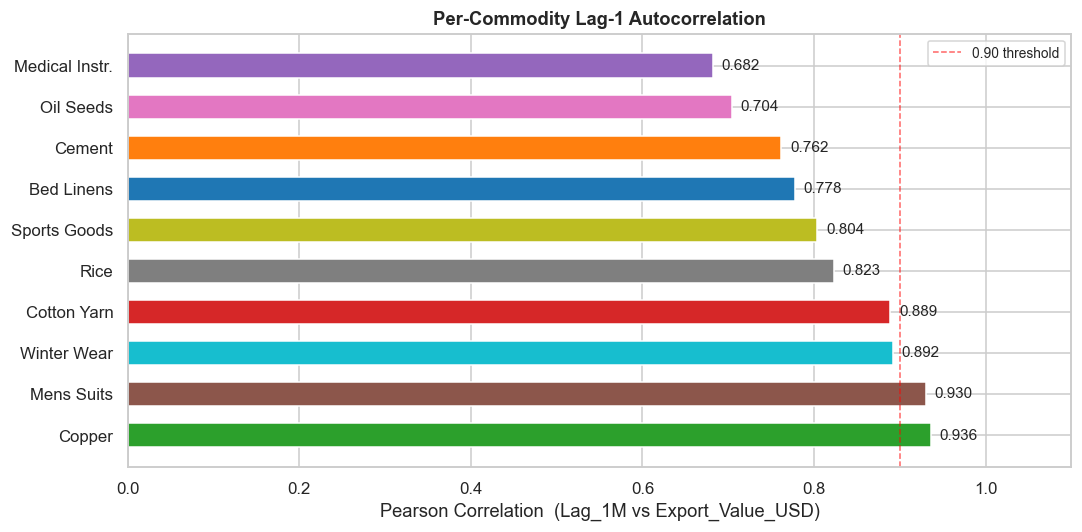

Copper has the lowest autocorrelation — due to zero-filled no-trade months that break the pattern.
Textile commodities (Bed Linens, Mens Suits, Cotton Yarn) show the strongest momentum.


In [18]:
# Per-commodity lag-1 correlation — is autocorrelation consistent across all commodities?
lag1_corr_per_comm = (
    df.groupby('Commodity')
    .apply(lambda g: g['Lag_1M'].corr(g['Export_Value_USD']))
    .sort_values(ascending=False)
    .round(3)
)

fig, ax = plt.subplots(figsize=(10, 5))
colors_comm = [COLORS[sorted_comms.index(c)] for c in lag1_corr_per_comm.index]
bars = ax.barh(lag1_corr_per_comm.index, lag1_corr_per_comm.values, 
               color=colors_comm, edgecolor='white', height=0.6)
ax.set_xlim(0, 1.1)
ax.axvline(0.9, color='red', linestyle='--', linewidth=1, alpha=0.6, label='0.90 threshold')
ax.set_xlabel('Pearson Correlation  (Lag_1M vs Export_Value_USD)')
ax.set_title('Per-Commodity Lag-1 Autocorrelation', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

for bar, val in zip(bars, lag1_corr_per_comm.values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

print('Copper has the lowest autocorrelation — due to zero-filled no-trade months that break the pattern.')
print('Textile commodities (Bed Linens, Mens Suits, Cotton Yarn) show the strongest momentum.')

---
<a id='8'></a>
## Section 8 — Key Insights Summary

### What We Learned from This EDA

---

#### 1. Extreme Scale Disparity Between Commodities
Bed Linens and Mens Suits export ~$200M+/month. Oil Seeds export ~$1M/month.  
The model must handle an 18x scale gap. Using `HS_Code` as a categorical feature in LightGBM/CatBoost lets the model learn a separate value function per commodity — the right approach.

#### 2. Long-Term Growth, But Not Uniform
- **Growing fast:** Copper, Winter Wear, Mens Suits  
- **Declining:** Cotton Yarn (lost ~60% of peak value; likely competitive pressure from Bangladesh/India)  
- **Stable:** Bed Linens, Medical Instruments, Sports Goods  
This means the `Year` and lag features need to capture these different trajectories per commodity.

#### 3. COVID-19 Left a Clear Scar (Mar–Sep 2020)
Visible as a dip in almost all commodity time series, most sharply in Copper and Cotton Yarn. The model will encounter these rows during training — they are real events, not noise.

#### 4. Strong Seasonality — Especially in Textiles
- **Winter Wear:** Peak in Jul–Sep (western retailers order for their winter 5–6 months ahead)
- **Rice:** Peak in Oct–Dec (post-harvest)
- **Bed Linens:** Relatively flat (global demand year-round)
The `Month_Sin` and `Month_Cos` cyclic features are validated as meaningful — seasonality is real.

#### 5. PKR Devaluation is the Biggest Macro Story
USD/PKR went from 85 (2010) to 280+ (2025) — a 3.3x devaluation. This inflates USD export values but doesn't necessarily mean more goods were exported. The model must learn this nuance through the `USD_PKR_Close` feature.

#### 6. US Consumer Confidence is Declining in 2025
Dropping from ~74 (2010) to 52.9 (Dec 2025). This is a headwind for Pakistan's apparel exports to Western markets. The model should capture this as a negative signal.

#### 7. Lag Features are the Strongest Predictors
All lag and rolling features show Pearson correlation > 0.90 with the target. Export momentum is real — this month's exports strongly resemble last month's. LightGBM will likely lean heavily on `Lag_1M` and `Rolling_3M_Avg`.

#### 8. Copper is the Wildcard
Lowest autocorrelation (~0.8), most erratic time series, zero-filled months. Expect the model to perform worst on Copper. It may need separate treatment or a higher error tolerance during evaluation.

---

### Modeling Implications for Notebook 3

| Finding | Impact on Model |
|---------|----------------|
| Scale disparity | Keep `HS_Code` as categorical — don't one-hot encode |
| Strong autocorrelation | `Lag_1M`, `Rolling_3M_Avg` will be top features |
| Seasonality confirmed | `Month_Sin`, `Month_Cos` will add meaningful signal |
| PKR devaluation trend | `Year` and `USD_PKR_Close` both carry trend information |
| Copper outlier | Monitor Copper MAPE separately during evaluation |
| COVID dip | No special treatment — it's real historical data the model should learn |

---

**Next step → Notebook 3: Model Training & Evaluation**